In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter
import pandas as pd
import scipy.optimize
import math

def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, math.sqrt(variance))

# read_colvar function which sorts colvar for unique entries from the back (i.e., second entry retained)
def read_colvar(colvar_file):

    data = np.loadtxt(colvar_file)
    # inverse order
    data = data[::-1]
    unique_idxs = np.array(np.unique(data[:,0], return_index=True)[1]).astype(int)[::-1] # find unique indices, first occurences
    data = data[unique_idxs]
    # original order
    data = data[::-1]

    return data

path = '/Volumes/Elements/PTM_project/PARK7/repeat_TYR_COORD_METAD_chainA_BF40/DATA_PLUMED/'

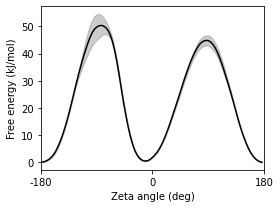

In [11]:
# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


fel_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,4]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)

plt.figure(figsize = (4,3))


plt.plot(x[:-1],mu,color = 'black')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)
    
# formatting

plt.xlabel('Zeta angle (deg)')
plt.xlim(-np.pi,np.pi)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=[-180,0,180])
plt.ylabel('Free energy (kJ/mol)')


plt.tight_layout()
plt.savefig('1D_avgFEL_zeta.png')

In [12]:
# calculate average fraction cis

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


cis_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,4]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[init_frame:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    frac_cis = np.sum(weights[cisframes])/np.sum(weights)
    cis_data.append(frac_cis)
    
# average and error

mu = [np.round(np.mean(cis_data),3)*100]
err = [np.round(np.std(cis_data)/np.sqrt(nsims),3)*100]

df = pd.DataFrame()
df['Avg %'] = mu
df['Err %']  = err
df.to_csv('avg_fraction_cis.csv')
df

,Avg %,Err %
0,40.4,1.2


In [13]:
print(mu)
print(err)
print(cis_data)

[40.400000000000006]
[1.2]
[0.396898374470458, 0.38409531745647, 0.43171590441455704]


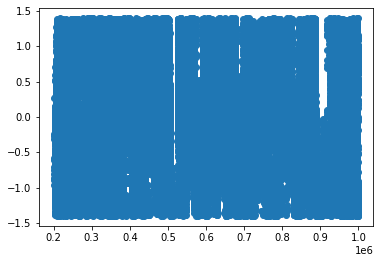

In [14]:
plt.scatter(data[:,0][init_frame:frame][cisframes],CV[init_frame:frame][cisframes])

In [15]:
# comparison with final bias

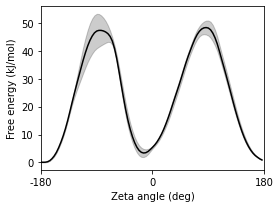

In [16]:
# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


fel_data = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'../final_bias_from_hills_1us/COLVAR_REW.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,4]
    frame = int(t*1000/20)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)

plt.figure(figsize = (4,3))


plt.plot(x[:-1],mu,color = 'black')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)
    
# formatting

plt.xlabel('Zeta angle (deg)')
plt.xlim(-np.pi,np.pi)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=[-180,0,180])
plt.ylabel('Free energy (kJ/mol)')


plt.tight_layout()
plt.savefig('1D_avgFEL_zeta_finalbias.png')

In [17]:
# calculate average fraction cis

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


cis_data = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'../final_bias_from_hills_1us/COLVAR_REW.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,4]
    frame = int(t*1000/20)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[init_frame:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    frac_cis = np.sum(weights[cisframes])/np.sum(weights)
    cis_data.append(frac_cis)
    
# average and error

mu = [np.round(np.mean(cis_data),3)*100]
err = [np.round(np.std(cis_data)/np.sqrt(nsims),3)*100]

df = pd.DataFrame()
df['Avg %'] = mu
df['Err %']  = err
df.to_csv('avg_fraction_cis_finalbias.csv')
df

,Avg %,Err %
0,22.2,8.2


In [18]:
cis_data

[0.1465204952449966, 0.09985030602632061, 0.4200817768567908]